# Classificando Imagens usando o modelo `mobilenetv3_small_100.lamb_in1k` (timm)

Este notebook demonstra como carregar um modelo pré-treinado da biblioteca **timm** (PyTorch Image Models) do Hugging Face para classificar as imagens atualmente localizadas na pasta `imagens` do seu projeto.

In [1]:
import urllib
import glob
from PIL import Image
from IPython.display import display
import torch
import timm
from timm.data import resolve_data_config
from timm.data.transforms_factory import create_transform

print("Bibliotecas carregadas com sucesso!")


Bibliotecas carregadas com sucesso!


### Baixando Rótulos Humanamente Legíveis do ImageNet
O modelo foi treinado no ImageNet (que tem 1000 classes numeradas). Vamos baixar o arquivo original de mapeamento de nomes, só pra gente ver a resposta da classificação em inglês amigável e não apenas com IDs.

In [2]:

url, filename = ("https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt", "imagenet_classes.txt")
try:
    urllib.request.urlretrieve(url, filename)
except Exception as e:
    print("Houve um problema ao baixar as categorias: ", e)

with open("imagenet_classes.txt", "r") as f:
    categories = [s.strip() for s in f.readlines()]
print(f"{len(categories)} categorias carregadas para formatação (ex: {categories[0]}, ...)")


1000 categorias carregadas para formatação (ex: tench, ...)


In [9]:
categories[0]


'tench'

### Inicializando o Modelo de Classificação e Configurando as Transformações da Imagem
Aqui carregamos o modelo pela hub, que na primeira execução fará um leve download, além das configurações para as "Transformações de imagem" para ficar igualzinho ao esperado pelo `MobileNet-V3` no treino original.

In [4]:

model_name = 'mobilenetv3_small_100.lamb_in1k'

try:

    print(f"Tentando carregar modelo: {model_name}")
    model = timm.create_model(model_name, pretrained=True)
except Exception as e:
    print(f"Erro ao carregar modelo normal, tentando via HF Hub: {e}")

    model = timm.create_model(f'hf-hub:timm/{model_name}', pretrained=True)

model.eval()
print(f"Modelo {model_name} carregado com sucesso.")

data_config = timm.data.resolve_model_data_config(model)
transform = timm.data.create_transform(**data_config, is_training=False)

print("Transformações configuradas:")


Tentando carregar modelo: mobilenetv3_small_100.lamb_in1k
Modelo mobilenetv3_small_100.lamb_in1k carregado com sucesso.
Transformações configuradas:


### Processamento do Diretório de Imagens
Agora, listamos as imagens na pasta e submetemos, prevendo individualmente com sua acurácia associada.

3 Imagens enfileiradas. Executando modelo...

Analisando agora: imagens\caoegato.jpg


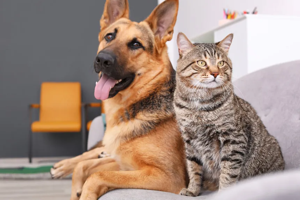


Resultado: Nesta imagem existe um(a) **Gato**.
Confiança do que é visto: 18.20%
Também foram detectados traços de: german shepherd

Analisando agora: imagens\passaro.jpg


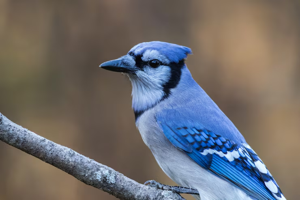


Resultado: Nesta imagem existe um(a) **Pássaro**.
Confiança do que é visto: 95.21%

Analisando agora: imagens\pizza.jpg


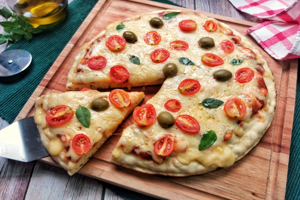


Resultado: Nesta imagem existe um(a) **Pizza**.
Confiança do que é visto: 86.11%


In [5]:
import re

def simplificar_categoria(nome):
    """Simplifica o Nome do ImageNet para termos mais comuns (ex: 'tabby cat' -> 'cat')"""
    nome = nome.lower()
    if 'cat' in nome:
        return 'Gato'
    if 'dog' in nome or 'terrier' in nome or 'retriever' in nome or 'hound' in nome:
        return 'Cachorro'
    if 'bird' in nome or 'jay' in nome or 'robin' in nome:
        return 'Pássaro'
    if 'pizza' in nome:
        return 'Pizza'
    return nome.split(',')[0]

lista_imagens = glob.glob("imagens/*")

if not lista_imagens:
    print("Nenhuma imagem encontrada em 'imagens/'. :(")
else:
    print(f"{len(lista_imagens)} Imagens enfileiradas. Executando modelo...")

    for caminho in lista_imagens:
        print(f"\n{'='*50}\nAnalisando agora: {caminho}\n{'='*50}")

        try:
             img = Image.open(caminho).convert('RGB')
        except Exception as e:
             print(f"Não foi possivel abrir o arquivo {caminho}: {e}")
             continue

        display(img.resize((300, 200)))

        img_tensor = transform(img).unsqueeze(0)
        with torch.no_grad():
            out = model(img_tensor)

        probabilidades = torch.nn.functional.softmax(out[0], dim=0)
        top5_prob, top5_catid = torch.topk(probabilidades, 5)

        agrupado = {}
        for i in range(top5_prob.size(0)):
            cat_bruta = categories[top5_catid[i]]
            simples = simplificar_categoria(cat_bruta)
            confianca = top5_prob[i].item() * 100

            if simples in agrupado:
                agrupado[simples] += confianca
            else:
                agrupado[simples] = confianca

        resultado_final = max(agrupado, key=agrupado.get)
        confianca_final = agrupado[resultado_final]

        print(f"\nResultado: Nesta imagem existe um(a) **{resultado_final}**.")
        print(f"Confiança do que é visto: {confianca_final:.2f}%")

        elementos_adicionais = [k for k, v in agrupado.items() if k != resultado_final and v > 10]
        if elementos_adicionais:
            print(f"Também foram detectados traços de: {', '.join(elementos_adicionais)}")
